# Phase 2: Functional Category Classification (8 Classes)

**Capstone Project: IoT Intrusion Detection System (CICIoT2023)**

### Objectives:
1. Advance from binary detection to classifying network traffic into **8 functional attack categories**:
   - `Benign` &mdash; Normal IoT operations
   - `DDoS` &mdash; Distributed Denial of Service floods
   - `DoS` &mdash; Denial of Service single-source floods
   - `Mirai` &mdash; IoT Botnet propagation and attacks
   - `Recon` &mdash; Port scans, host discovery, ping sweeps, vulnerability scans
   - `Spoofing` &mdash; ARP and DNS spoofing
   - `Web` &mdash; Stealthy application-layer attacks (SQLi, XSS, Command Injection, Browser Hijacking)
   - `BruteForce` &mdash; Dictionary password brute forcing
2. Mitigate severe multi-class category imbalance using cost-sensitive balanced weighting.
3. Compare 5 model architectures on Macro F1, Per-Class Recall, and per-flow inference latency.
4. Inspect 8&times;8 confusion matrices to identify inter-class confusion patterns.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from src.config import SAMPLE_FILE, TABLES_DIR, FIGURES_DIR, EIGHT_CLASSES
from src.preprocessing import prepare_dataset
from src.evaluate import evaluate_predictions, measure_inference_latency, plot_confusion_matrix

sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Data & Verify 8-Class Distributions

In [2]:
df = pd.read_csv(SAMPLE_FILE)
print(f"Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

X_train, X_test, y_train, y_test, class_names, scaler = prepare_dataset(
    df, target_type="category", test_size=0.2, random_state=42, scale_features=True
)

print(f"X_train Shape: {X_train.shape} | X_test Shape: {X_test.shape}")
print(f"Categories: {class_names}")

dist_df = pd.DataFrame({
    'Category': class_names,
    'Train Count': pd.Series(y_train).value_counts().sort_index().values,
    'Test Count': pd.Series(y_test).value_counts().sort_index().values,
})
dist_df['Total'] = dist_df['Train Count'] + dist_df['Test Count']
dist_df['Share (%)'] = np.round((dist_df['Total'] / len(df)) * 100, 2)
print("\n===== 8-Class Dataset Distribution =====")
print(tabulate(dist_df, headers='keys', tablefmt='github', showindex=False))

Loaded dataset: 529,562 rows x 40 columns


X_train Shape: (423649, 39) | X_test Shape: (105913, 39)
Categories: ['Benign', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Web', 'BruteForce']

===== 8-Class Dataset Distribution =====
| Category   |   Train Count |   Test Count |   Total |   Share (%) |
|------------|---------------|--------------|---------|-------------|
| Benign     |         32000 |         8000 |   40000 |        7.55 |
| DDoS       |        173324 |        43331 |  216655 |       40.91 |
| DoS        |         64000 |        16000 |   80000 |       15.11 |
| Mirai      |         48000 |        12000 |   60000 |       11.33 |
| Recon      |         64577 |        16145 |   80722 |       15.24 |
| Spoofing   |         32000 |         8000 |   40000 |        7.55 |
| Web        |          6403 |         1601 |    8004 |        1.51 |
| BruteForce |          3345 |          836 |    4181 |        0.79 |


## 2. Benchmark Summary Across All Models

In [3]:
benchmark_csv = TABLES_DIR / "category8_models_benchmark.csv"
if benchmark_csv.exists():
    results_df = pd.read_csv(benchmark_csv)
    print("\n===== Phase 2: 8-Class Benchmark Results =====")
    display_table = results_df.copy()
    display_table['Accuracy'] = display_table['Accuracy'].apply(lambda x: f"{x*100:.2f}%")
    display_table['Macro F1'] = display_table['Macro F1'].apply(lambda x: f"{x:.4f}")
    display_table['Weighted F1'] = display_table['Weighted F1'].apply(lambda x: f"{x:.4f}")
    display_table['ROC-AUC (OVR)'] = display_table['ROC-AUC (OVR)'].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
    display_table['Latency (us/flow)'] = display_table['Latency (us/flow)'].apply(lambda x: f"{x:.2f} us")
    display_table['Throughput (flows/s)'] = display_table['Throughput (flows/s)'].apply(lambda x: f"{x:,} fps")
    print(tabulate(display_table, headers="keys", tablefmt="github", showindex=False))
else:
    print("Benchmark table not found. Run 'python -m src.train_category_8class' first.")


===== Phase 2: 8-Class Benchmark Results =====
| Model               | Accuracy   |   Macro F1 |   Weighted F1 |   Macro Precision |   Macro Recall |   ROC-AUC (OVR) |   Train Time (s) | Latency (us/flow)   | Throughput (flows/s)   |
|---------------------|------------|------------|---------------|-------------------|----------------|-----------------|------------------|---------------------|------------------------|
| xgboost             | 82.87%     |     0.6876 |        0.8241 |          0.826929 |       0.663738 |          0.9752 |            38.53 | 6.24 us             | 160,318 fps            |
| lightgbm            | 78.82%     |     0.6876 |        0.8039 |          0.68198  |       0.769028 |          0.9785 |            33.67 | 18.84 us            | 53,087 fps             |
| random_forest       | 78.17%     |     0.6814 |        0.7974 |          0.676015 |       0.754243 |          0.9768 |            13.75 | 8.65 us             | 115,623 fps            |
| pytorch_dnn    

## 3. Accuracy vs. Macro F1 & Latency Comparison

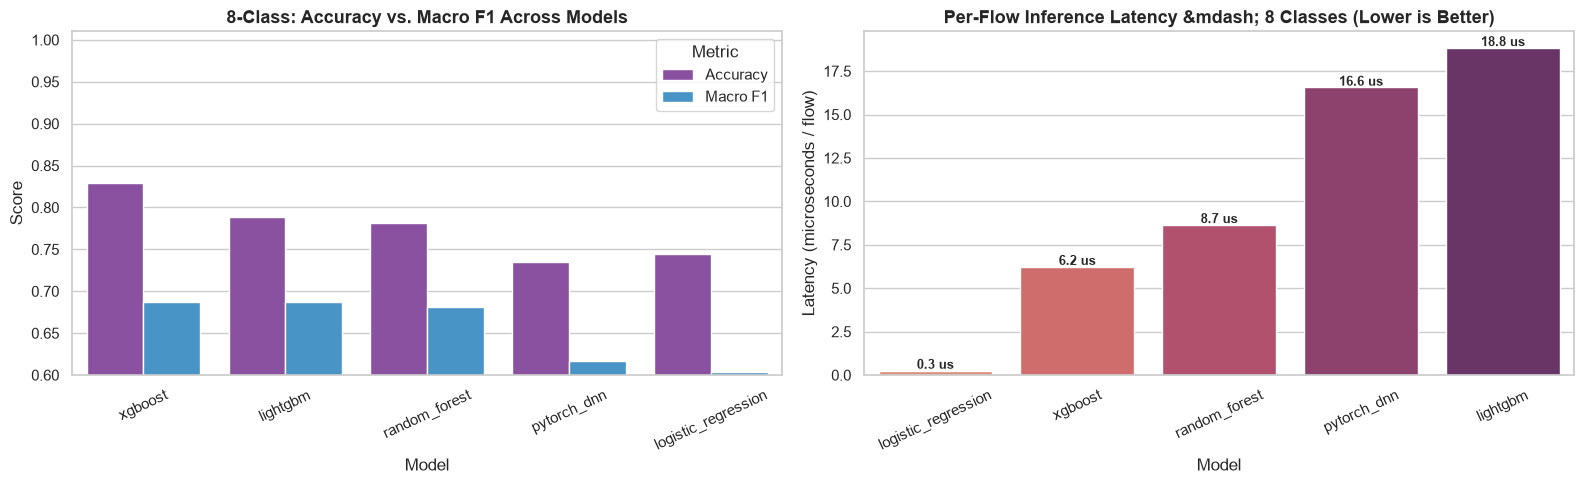

In [4]:
if benchmark_csv.exists():
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Plot 1: Macro F1 vs Accuracy
    plot_df = results_df.melt(id_vars=['Model'], value_vars=['Accuracy', 'Macro F1'], var_name='Metric', value_name='Score')
    sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', ax=axes[0], palette=['#8e44ad', '#3498db'])
    axes[0].set_title("8-Class: Accuracy vs. Macro F1 Across Models", fontsize=13, fontweight='bold')
    axes[0].set_ylim([0.60, 1.01])
    axes[0].tick_params(axis='x', rotation=25)
    
    # Plot 2: Inference Latency
    sns.barplot(data=results_df.sort_values(by='Latency (us/flow)'), x='Model', y='Latency (us/flow)', hue='Model', ax=axes[1], palette='flare', legend=False)
    axes[1].set_title("Per-Flow Inference Latency &mdash; 8 Classes (Lower is Better)", fontsize=13, fontweight='bold')
    axes[1].set_ylabel("Latency (microseconds / flow)")
    axes[1].tick_params(axis='x', rotation=25)
    for i, row in enumerate(results_df.sort_values(by='Latency (us/flow)').itertuples()):
        axes[1].text(i, row._9 + 0.1, f"{row._9:.1f} us", ha='center', fontsize=9, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

## 4. 8&times;8 Normalized Confusion Matrix Heatmaps

Found 5 8-class confusion matrix figures:
Displaying: category8_cm_lightgbm.png


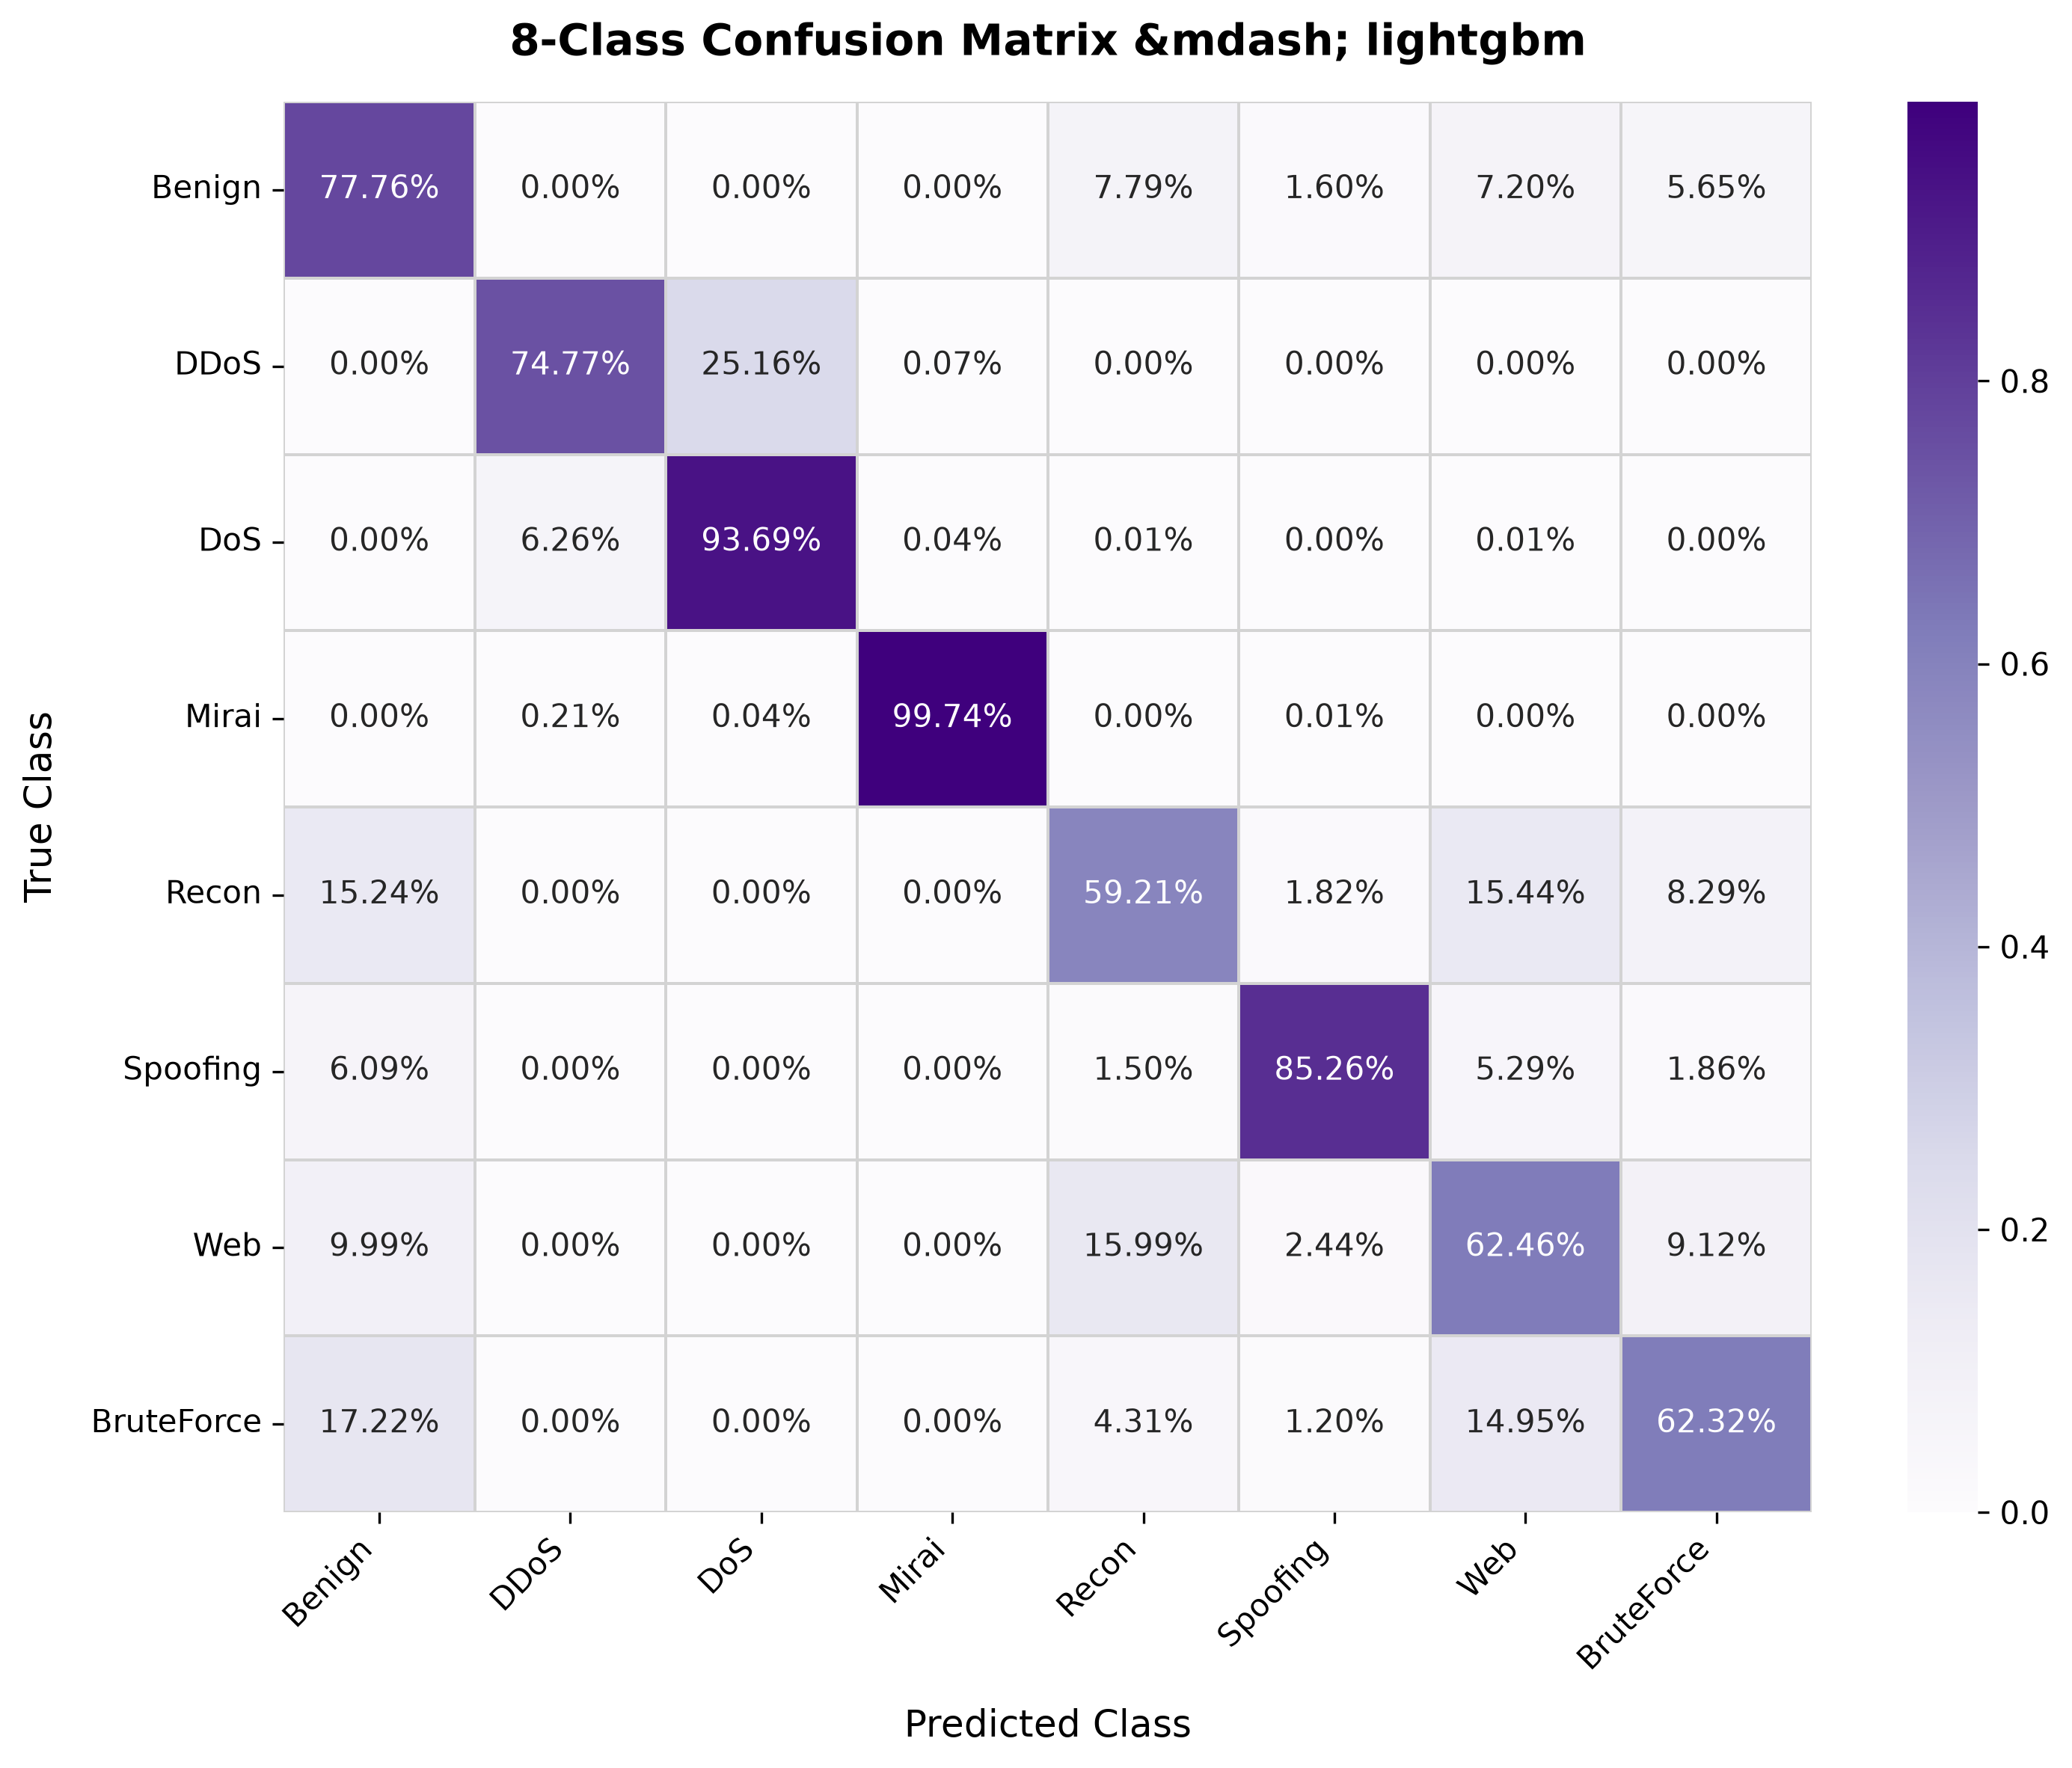

Displaying: category8_cm_logistic_regression.png


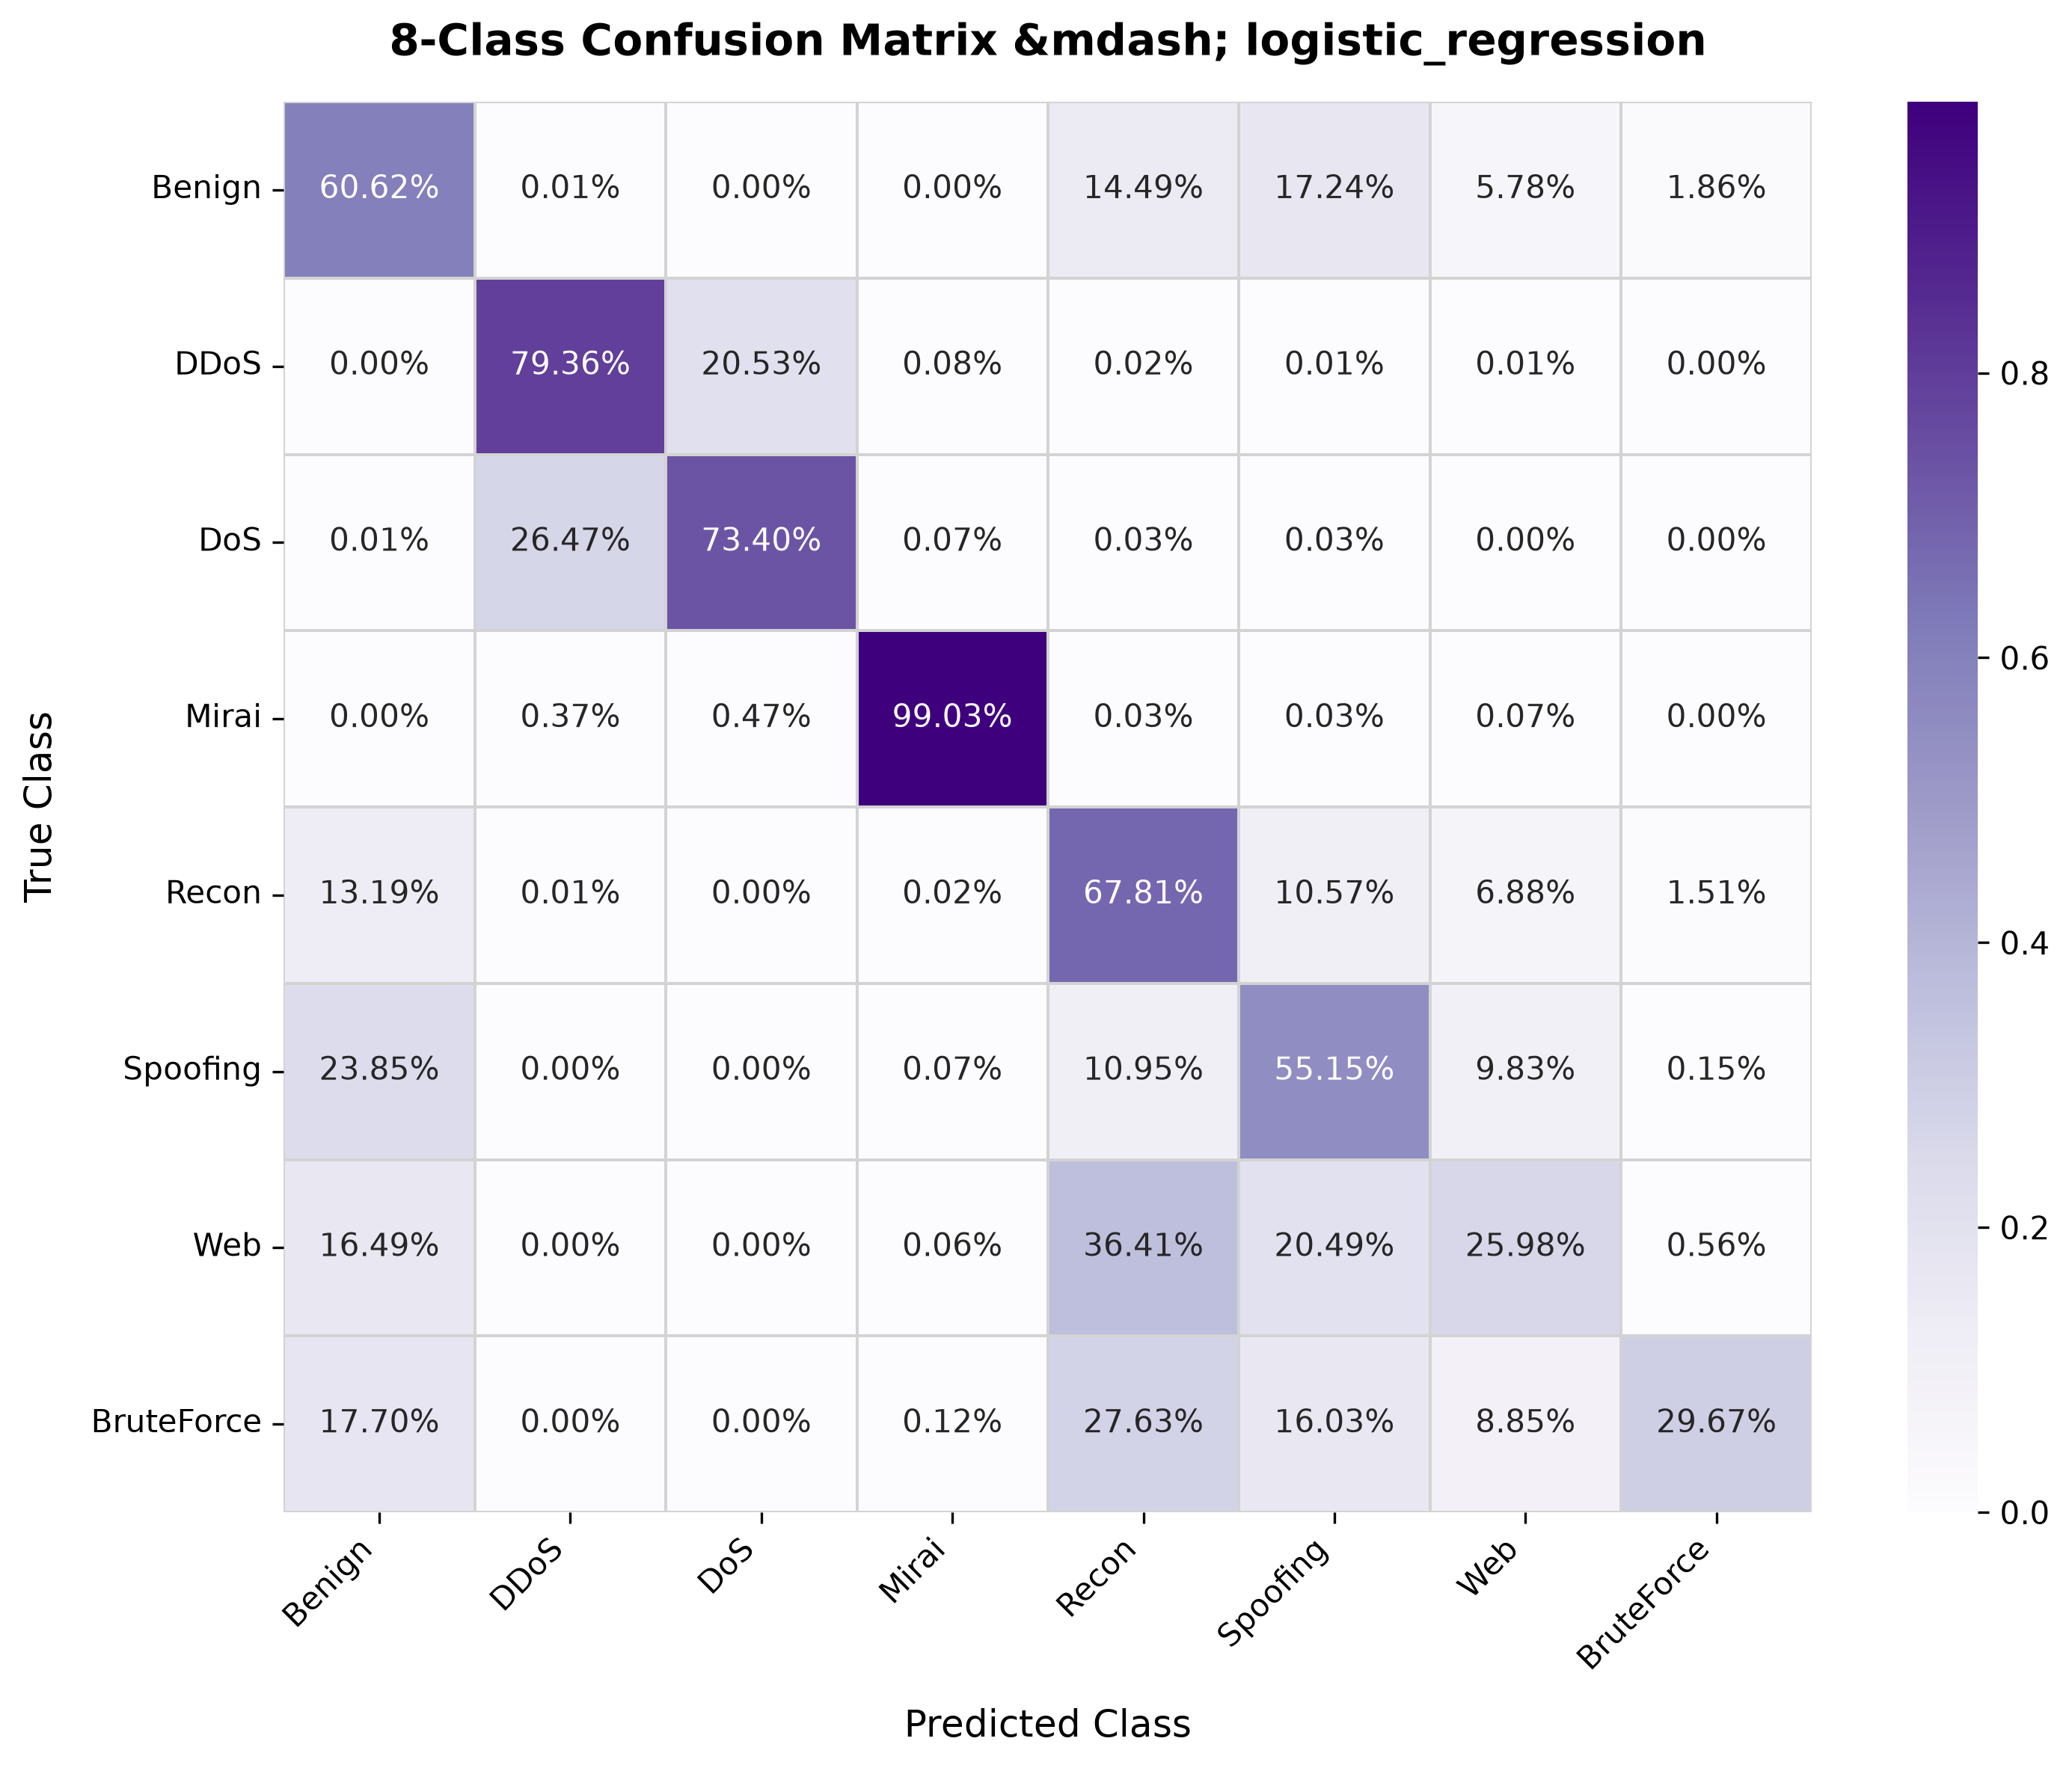

Displaying: category8_cm_pytorch_dnn.png


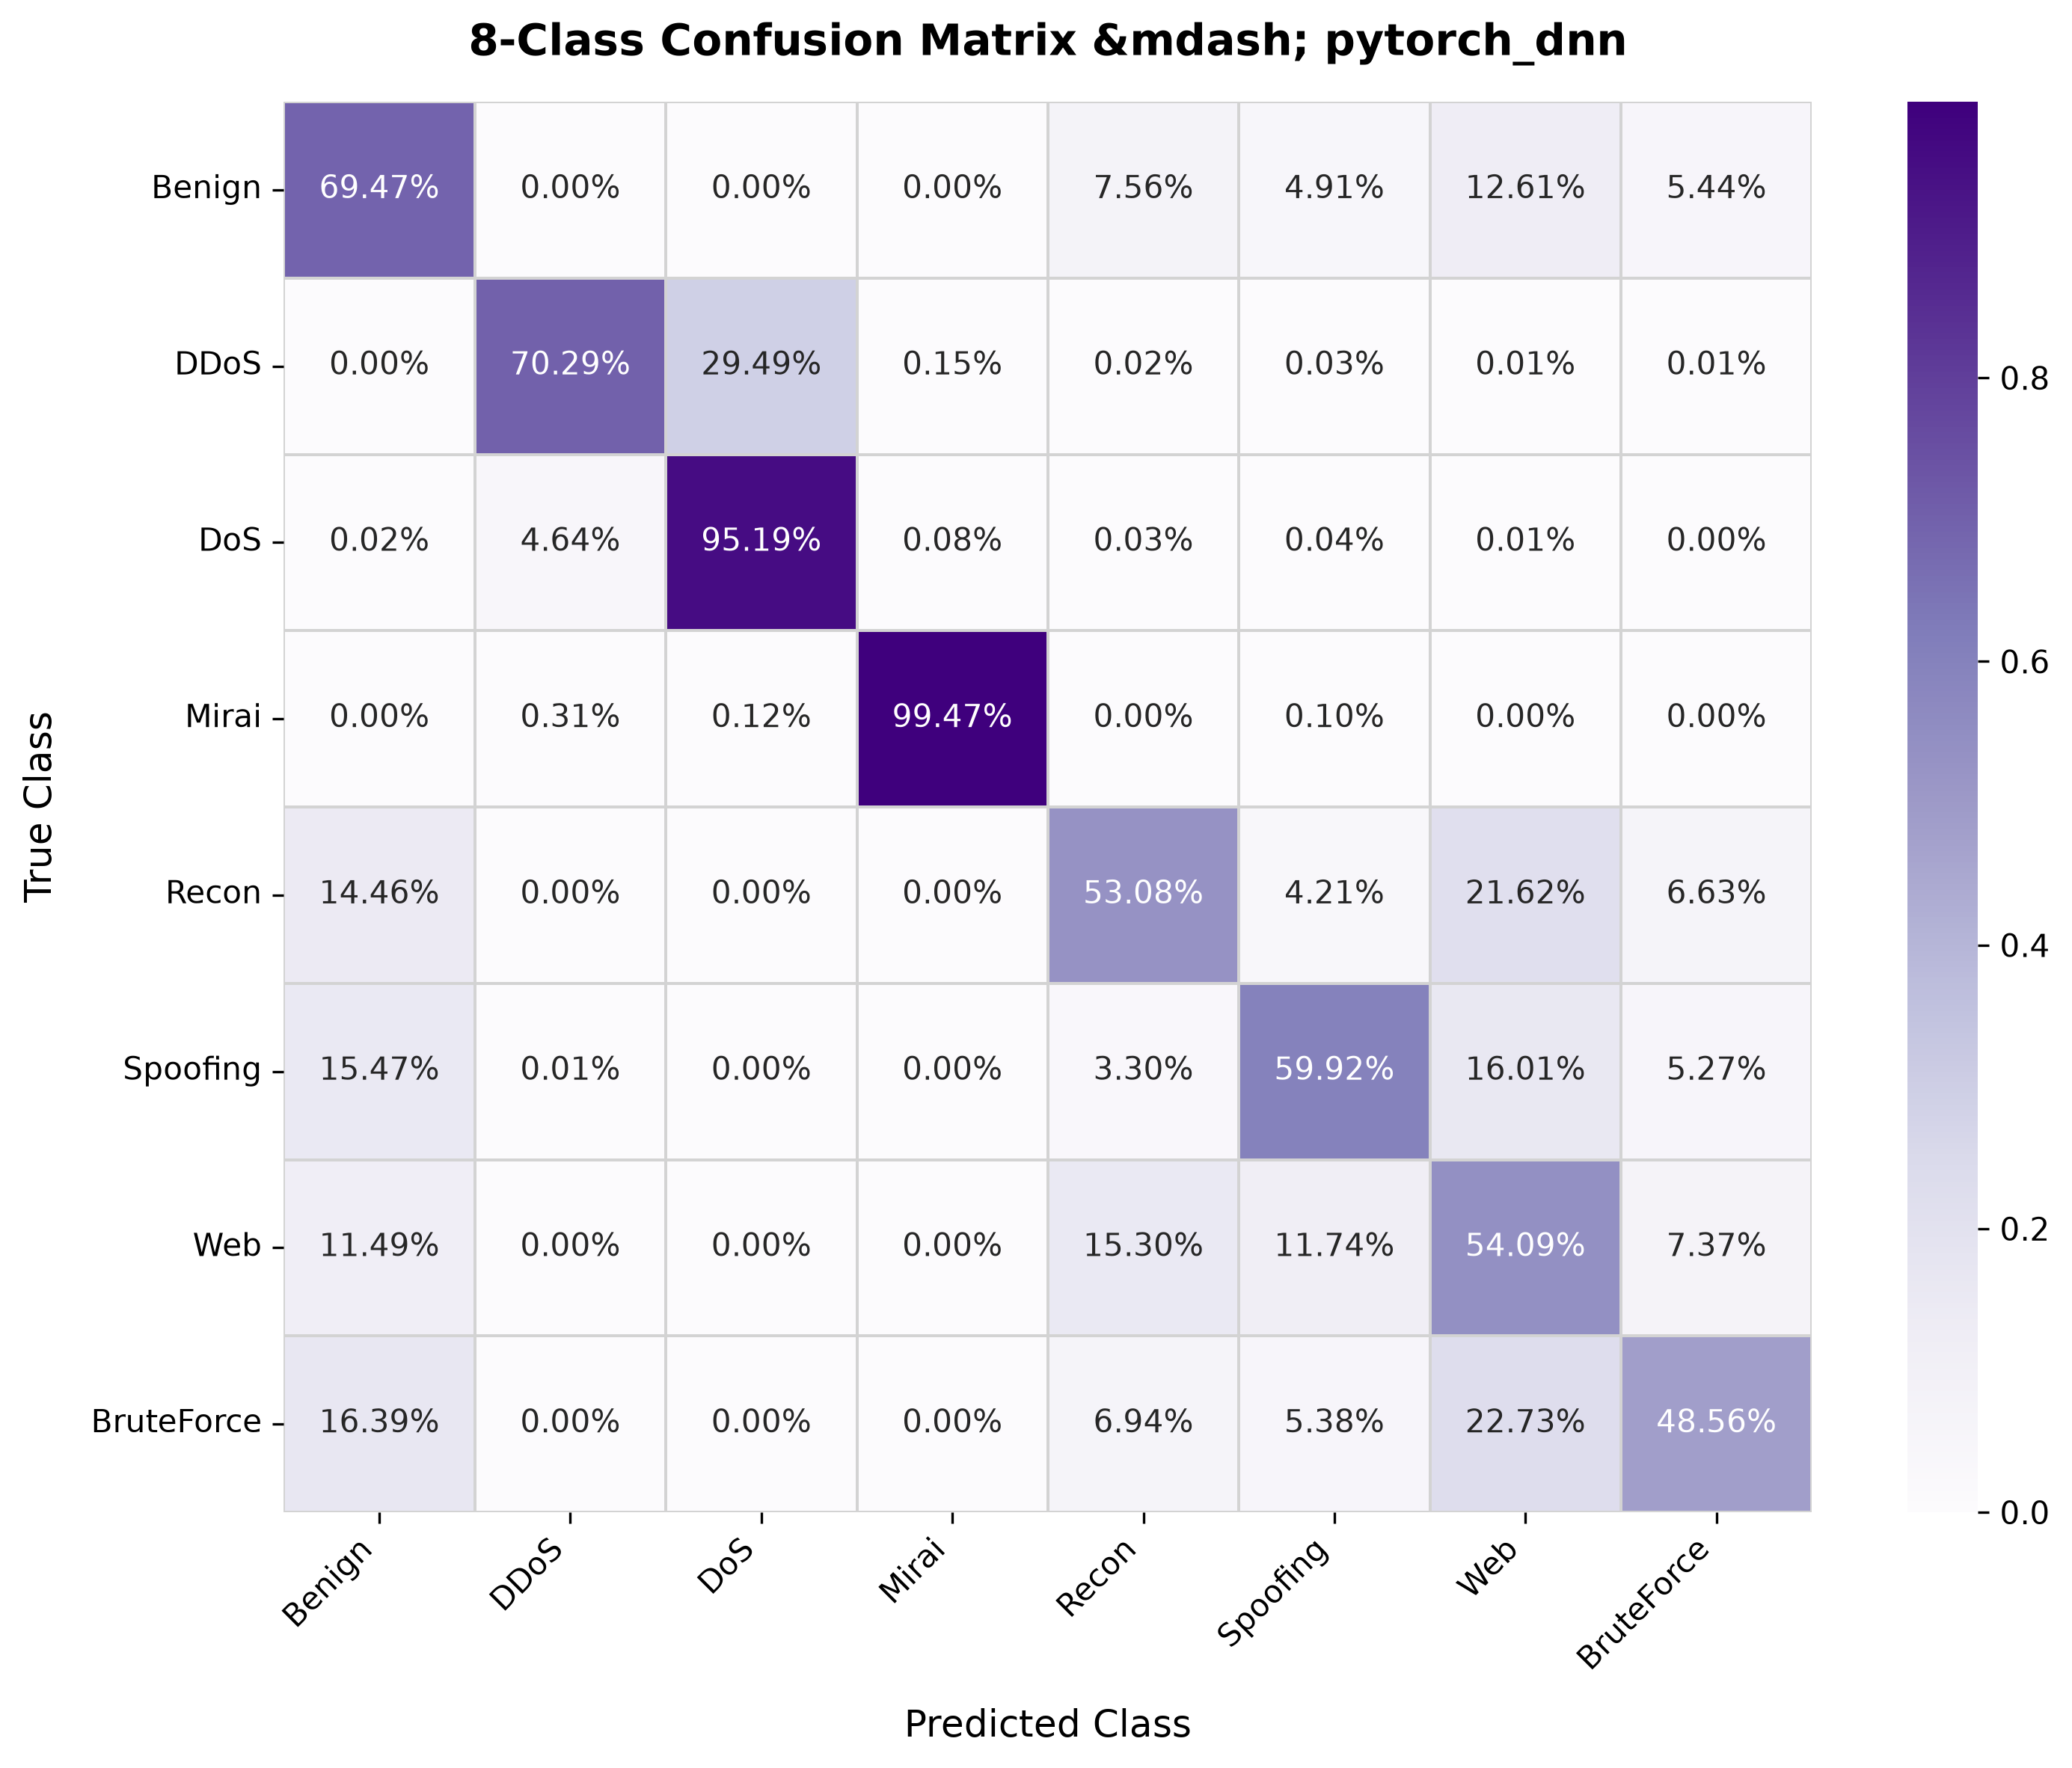

Displaying: category8_cm_random_forest.png


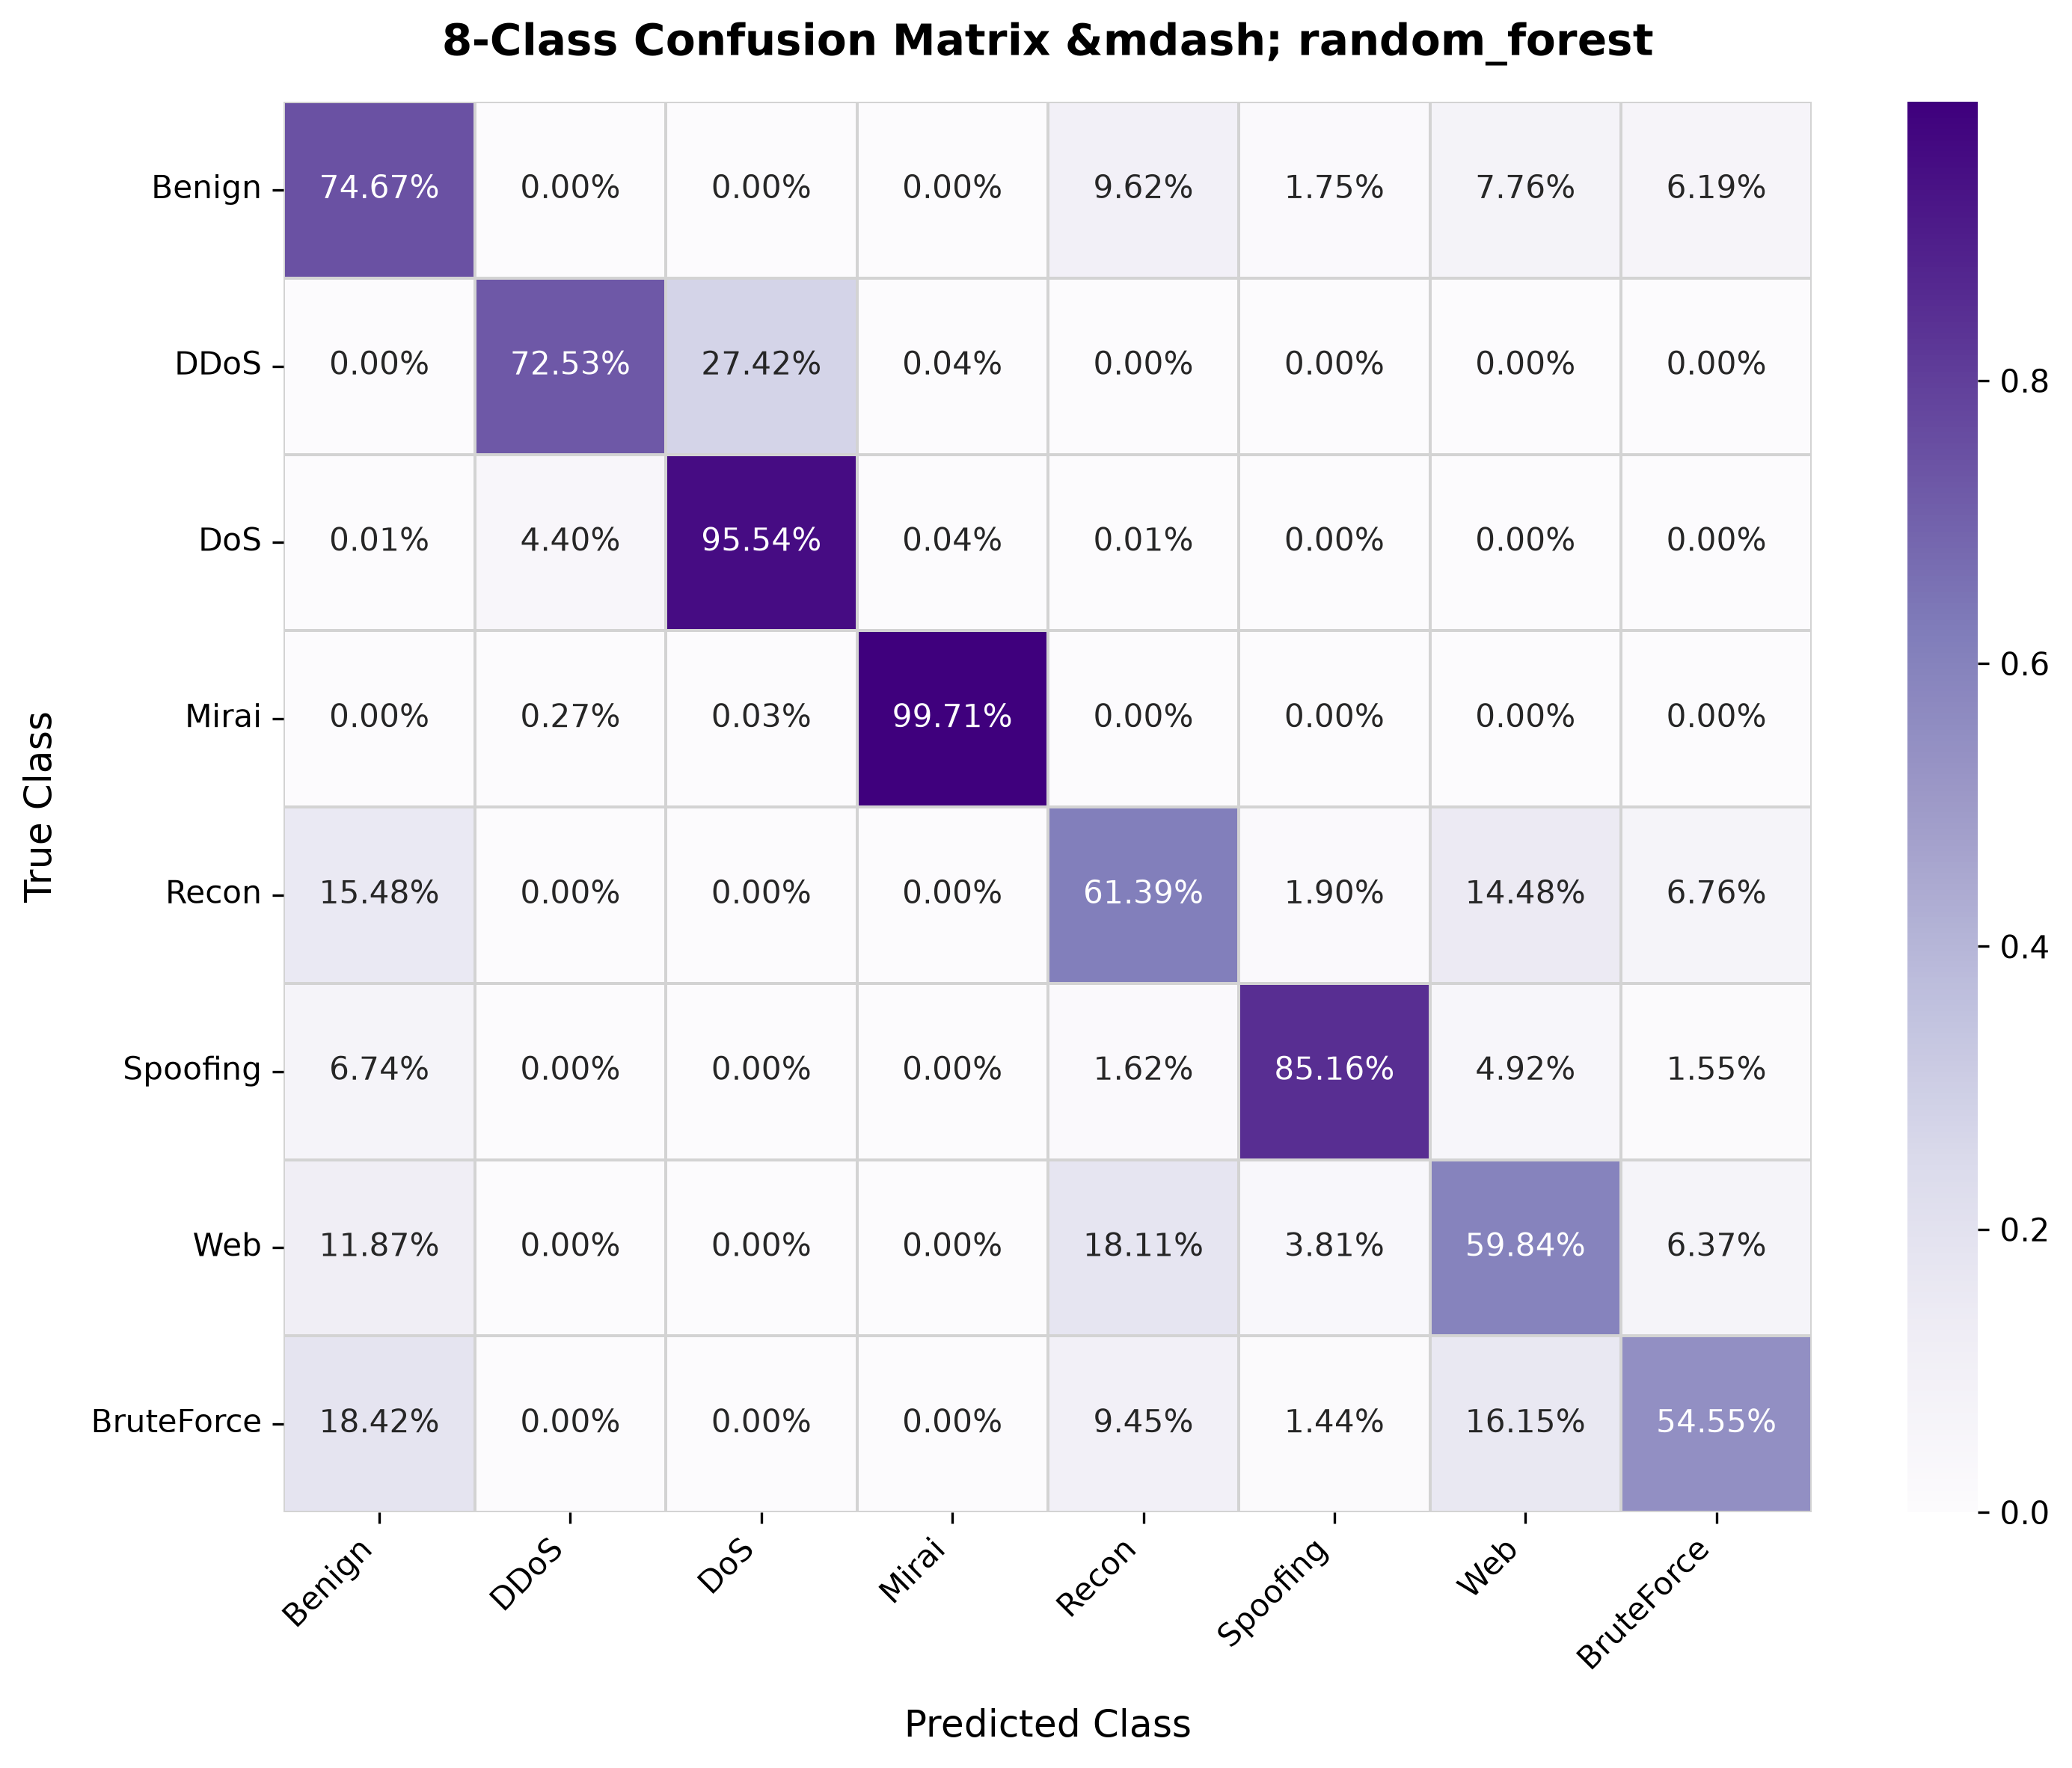

Displaying: category8_cm_xgboost.png


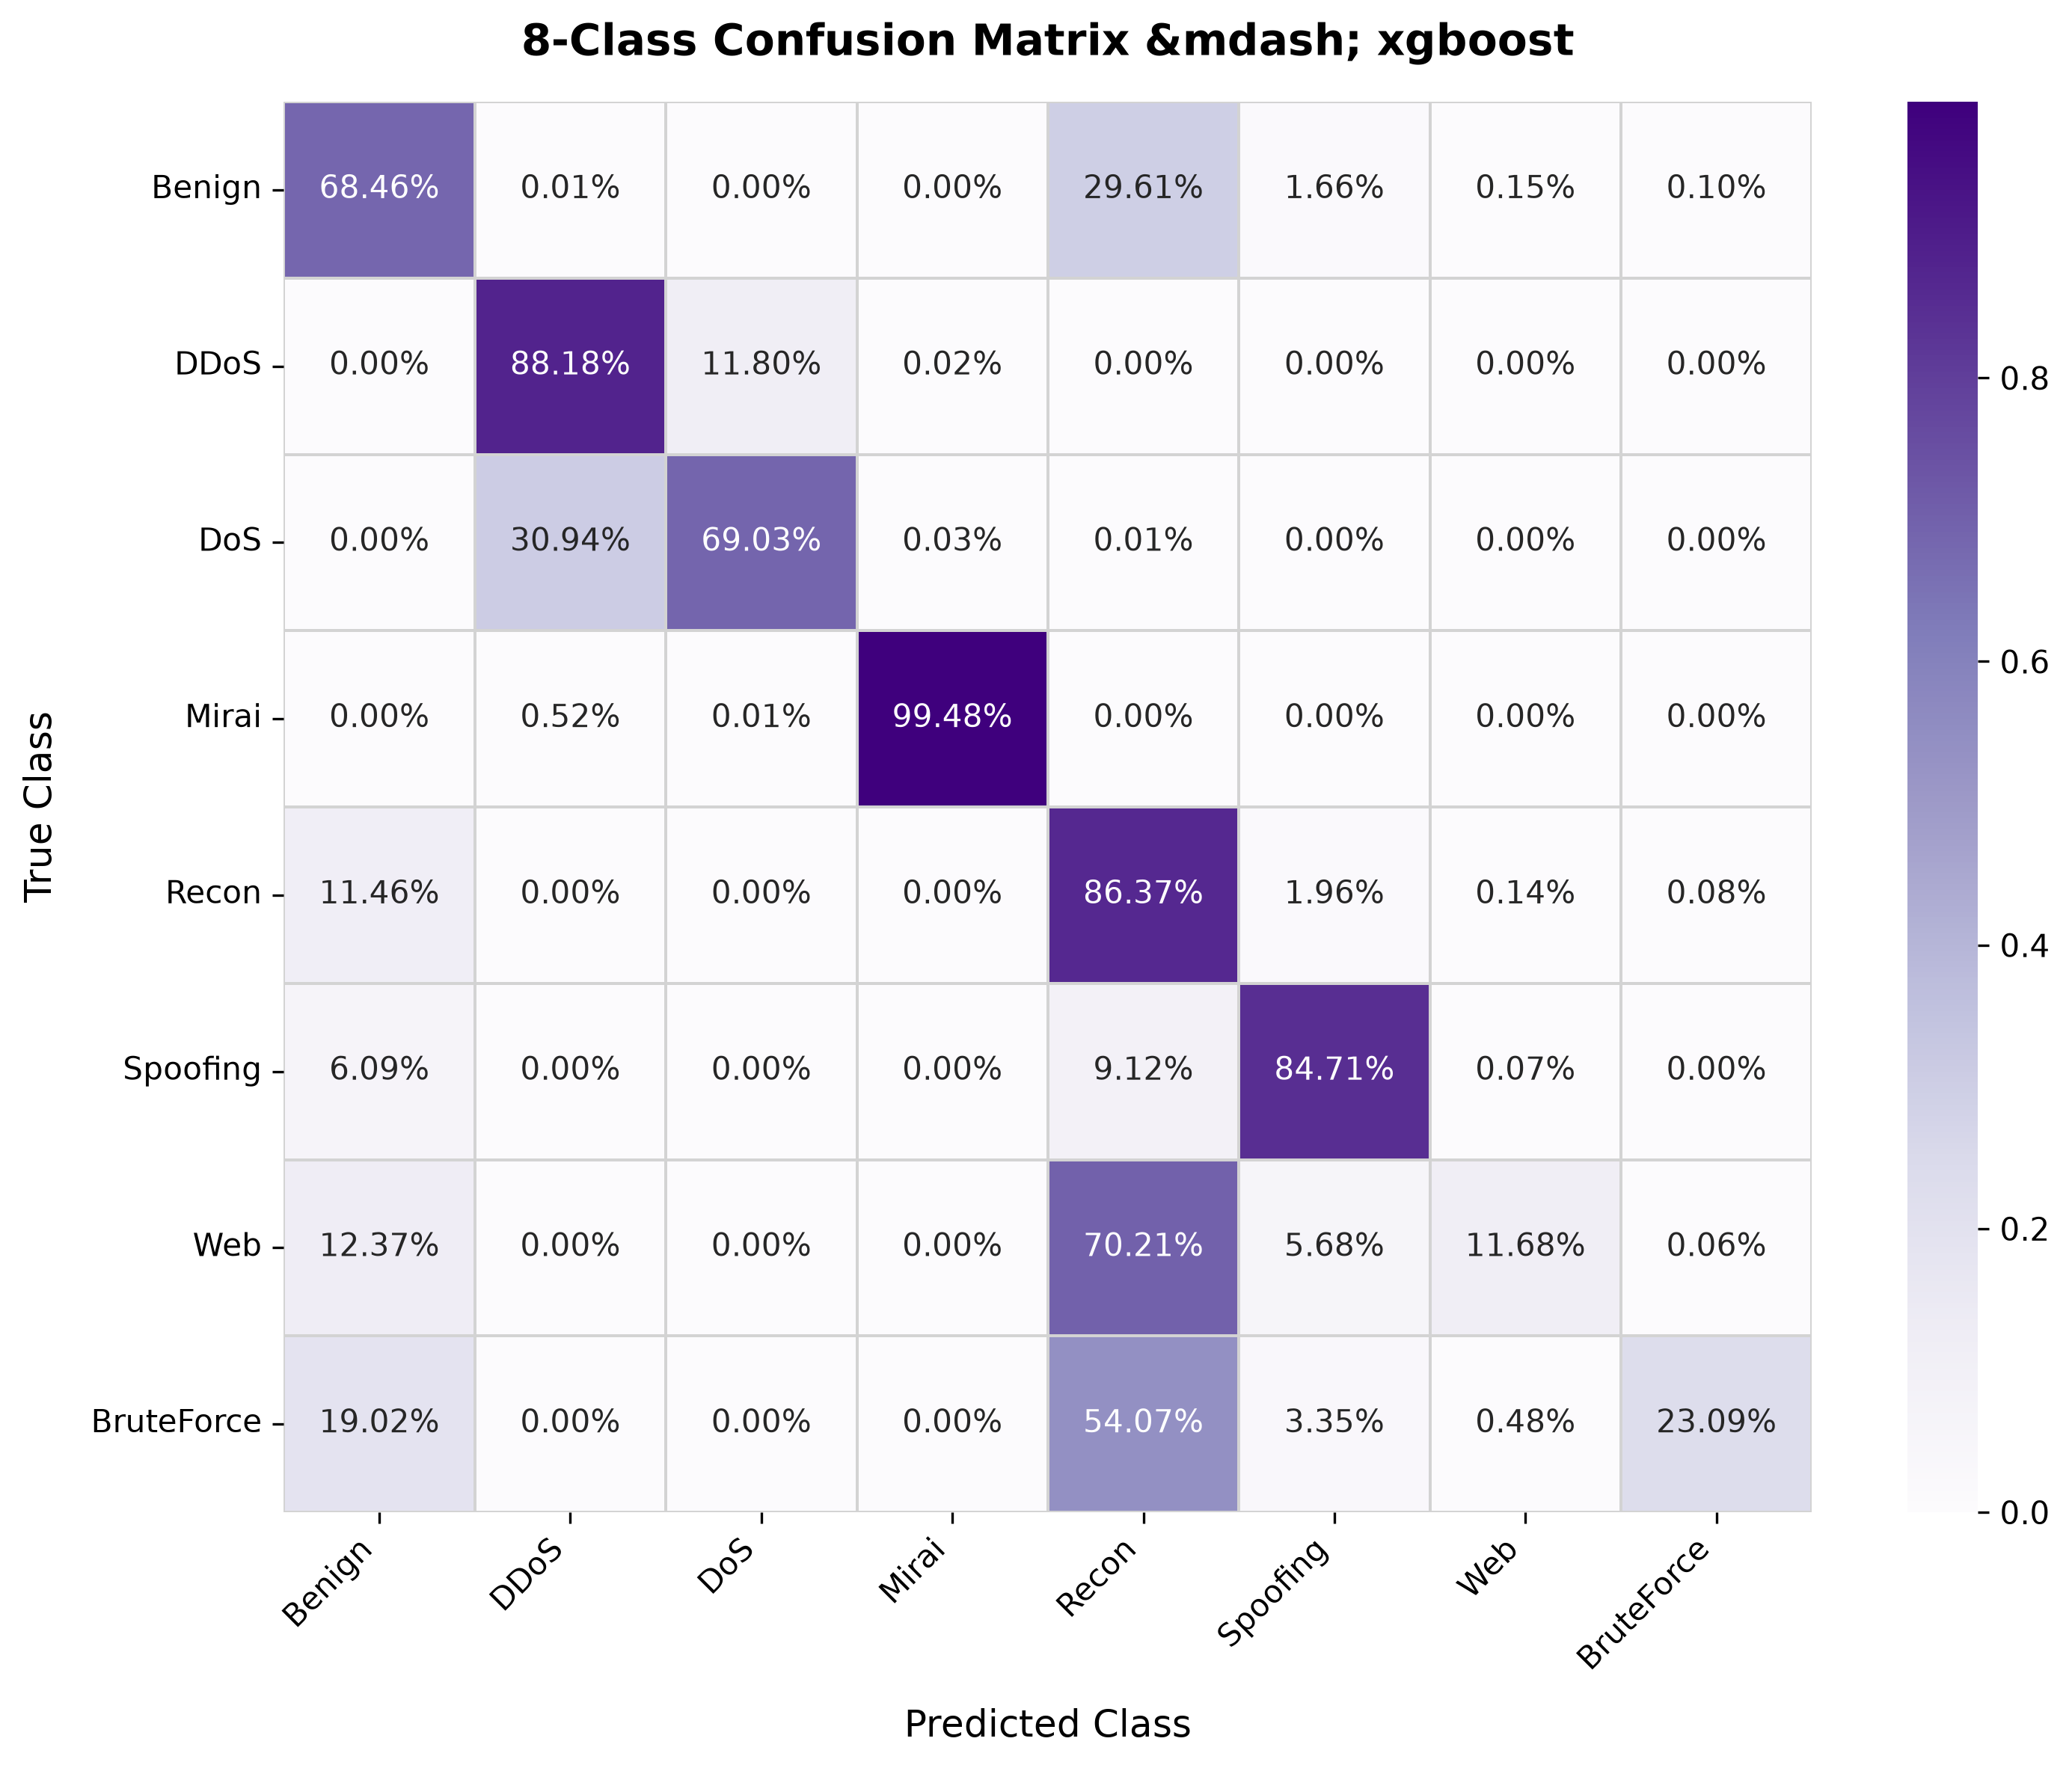

In [5]:
from IPython.display import Image, display

cm_files = sorted(list(FIGURES_DIR.glob("category8_cm_*.png")))
print(f"Found {len(cm_files)} 8-class confusion matrix figures:")
for cm_f in cm_files:
    print(f"Displaying: {cm_f.name}")
    display(Image(filename=str(cm_f), width=750))

## 5. Per-Class Precision, Recall, and F1 Breakdown

In [6]:
reports_json = TABLES_DIR / "category8_per_class_reports.json"
if reports_json.exists():
    with open(reports_json, 'r') as f:
        all_reports = json.load(f)
    
    # Focus on top model (e.g. XGBoost or LightGBM)
    top_model = results_df.iloc[0]['Model'] if benchmark_csv.exists() else 'xgboost'
    if top_model in all_reports:
        top_report = all_reports[top_model]
        per_class_rows = []
        for cls_name in class_names:
            if cls_name in top_report:
                r = top_report[cls_name]
                per_class_rows.append({
                    'Category': cls_name,
                    'Precision': f"{r['precision']:.4f}",
                    'Recall': f"{r['recall']:.4f}",
                    'F1-Score': f"{r['f1-score']:.4f}",
                    'Support': f"{int(r['support']):,}",
                })
        per_class_df = pd.DataFrame(per_class_rows)
        print(f"\n===== Per-Class Performance Breakdown: Top Model [{top_model}] =====")
        print(tabulate(per_class_df, headers='keys', tablefmt='github', showindex=False))
else:
    print("Per-class reports not found.")


===== Per-Class Performance Breakdown: Top Model [xgboost] =====
| Category   |   Precision |   Recall |   F1-Score |   Support |
|------------|-------------|----------|------------|-----------|
| Benign     |      0.6702 |   0.6846 |     0.6773 |     8,000 |
| DDoS       |      0.884  |   0.8818 |     0.8829 |    43,331 |
| DoS        |      0.6836 |   0.6903 |     0.6869 |    16,000 |
| Mirai      |      0.9989 |   0.9948 |     0.9968 |    12,000 |
| Recon      |      0.7488 |   0.8637 |     0.8022 |    16,145 |
| Spoofing   |      0.9227 |   0.8471 |     0.8833 |     8,000 |
| Web        |      0.8095 |   0.1168 |     0.2041 |     1,601 |
| BruteForce |      0.8977 |   0.2309 |     0.3673 |       836 |
